<a href="https://colab.research.google.com/github/mixxr/gcolab-ml/blob/main/funnel/02_how_computers_see_molecules.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Episode 2 — How Computers See Molecules
**Drug Discovery in Code** · [Life Sciences AI Applications]
Before we can filter, search, or model molecules, a computer needs to *represent* them. There are
three representations that everything later depends on:
1. the **molecular graph** (atoms + bonds),
2. **descriptors** (a vector of numbers), and
3. **fingerprints** (a bit vector of substructures).
We'll build all three, then use fingerprints to measure how *similar* two molecules are.
> Educational only — not medical advice.

In [2]:
! wget https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh
! bash Miniconda3-latest-Linux-x86_64.sh -b -f -p /usr/local

--2026-10-09 07:35:49--  https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh
Resolving repo.anaconda.com (repo.anaconda.com)... 104.16.32.241, 104.16.191.158, 2606:4700::6810:20f1, ...
Connecting to repo.anaconda.com (repo.anaconda.com)|104.16.32.241|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 197973354 (189M) [application/octet-stream]
Saving to: ‘Miniconda3-latest-Linux-x86_64.sh’

Miniconda3-latest-L 100%[===================>] 188.80M   200MB/s    in 0.9s    

2026-10-09 07:35:50 (200 MB/s) - ‘Miniconda3-latest-Linux-x86_64.sh’ saved [197973354/197973354]

PREFIX=/usr/local
Unpacking bootstrapper...
Unpacking payload...

Installing base environment...

Preparing transaction: ...working... done
Executing transaction: ...working... done
installation finished.
    You currently have a PYTHONPATH environment variable set. This may cause
    unexpected behavior when running the Python interpreter in Miniconda3.
    For best results, please 

In [3]:
import sys
!{sys.executable} -m pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.1/38.1 MB 15.2 MB/s eta 0:00:00


## Setup

In [6]:
from rdkit import Chem
from rdkit.Chem import Draw, Descriptors, rdFingerprintGenerator, DataStructs
from rdkit.Chem.Draw import rdMolDraw2D

# mol = Chem.MolFromSmiles("CC(=O)Oc1ccccc1C(=O)O")
mol = Chem.MolFromSmiles("CN1C=NC2=C1C(=O)N(C(=O)N2C)C")

## 1. Molecules as graphs
Under the hood, a molecule is a **graph**: atoms are nodes, bonds are edges. RDKit lets you walk them.

Atoms: 14  Bonds: 15
Atom symbols: ['C', 'N', 'C', 'N', 'C', 'C', 'C', 'O', 'N', 'C', 'O', 'N', 'C', 'C']


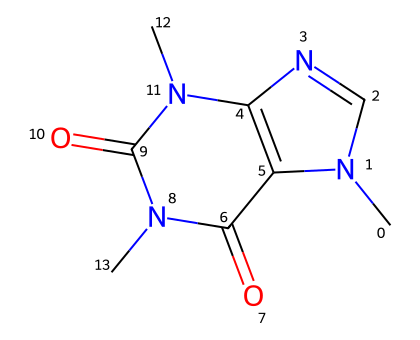

In [7]:
print("Atoms:", mol.GetNumAtoms(), " Bonds:", mol.GetNumBonds())
print("Atom symbols:", [a.GetSymbol() for a in mol.GetAtoms()])

# draw with atom indices to see the graph
d = rdMolDraw2D.MolDraw2DCairo(420, 340)
d.drawOptions().addAtomIndices = True
rdMolDraw2D.PrepareAndDrawMolecule(d, mol)
d.FinishDrawing()
from IPython.display import Image as IPyImage
IPyImage(d.GetDrawingText())

## 2. Descriptors — a molecule as a vector of numbers
A **descriptor** is any number computed from the structure. Stack several together and a molecule
becomes a feature vector — which is exactly what a machine-learning model needs (Episode 6).

In [8]:
descriptors = {
    "MolWt":          round(Descriptors.MolWt(mol), 1),
    "LogP":           round(Descriptors.MolLogP(mol), 2),
    "TPSA":           round(Descriptors.TPSA(mol), 1),
    "RotatableBonds": Descriptors.NumRotatableBonds(mol),
    "AromaticRings":  Descriptors.NumAromaticRings(mol),
    "HDonors":        Descriptors.NumHDonors(mol),
    "HAcceptors":     Descriptors.NumHAcceptors(mol),
}
descriptors

{'MolWt': 194.2,
 'LogP': -1.03,
 'TPSA': 61.8,
 'RotatableBonds': 0,
 'AromaticRings': 2,
 'HDonors': 0,
 'HAcceptors': 3}

## 3. Fingerprints — substructures as a bit vector
A **Morgan fingerprint** (ECFP) scans every atom's neighbourhood and flips on bits for the
substructures it finds. The result is a fixed-length bit vector — a molecule's chemical 'barcode'.

In [9]:
gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
fp = gen.GetFingerprint(mol)

print("Fingerprint length:", fp.GetNumBits())
print("On-bits (substructures present):", len(list(fp.GetOnBits())))

Fingerprint length: 2048
On-bits (substructures present): 25


## Comparing molecules — Tanimoto similarity
Similarity search is where fingerprints are useful and the descriptor dict isn't.

Two fingerprints can be compared with the **Tanimoto** coefficient (0 = nothing in common, 1 =
identical). This is the engine behind similarity search in Episode 5.

Fingerprint: <rdkit.DataStructs.cDataStructs.ExplicitBitVect object at 0x7b87917d12a0>
mol vs salicylic acid:            0.07
mol vs caffeine:                  1.0
mol vs aspirine:                  0.09
salicylic acid vs aspirine:       0.45


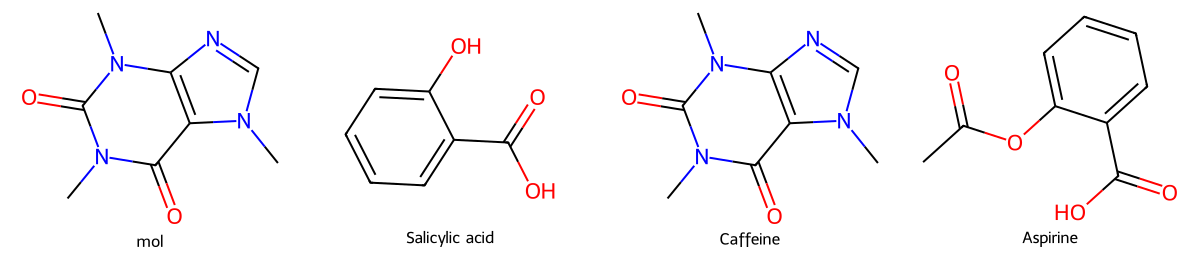

In [13]:
salicylic = Chem.MolFromSmiles("O=C(O)c1ccccc1O")   # aspirine's close cousin
caffeine  = Chem.MolFromSmiles("CN1C=NC2=C1C(=O)N(C(=O)N2C)C")  # identical
aspirine = Chem.MolFromSmiles("CC(=O)Oc1ccccc1C(=O)O") # unrelated

fp_s = gen.GetFingerprint(salicylic)
fp_c = gen.GetFingerprint(caffeine)
fp_a = gen.GetFingerprint(aspirine)

print("mol vs salicylic acid:           ", round(DataStructs.TanimotoSimilarity(fp, fp_s), 2))
print("mol vs caffeine:                 ", round(DataStructs.TanimotoSimilarity(fp, fp_c), 2))
print("mol vs aspirine:                 ", round(DataStructs.TanimotoSimilarity(fp, fp_a), 2))
print("salicylic acid vs aspirine:      ", round(DataStructs.TanimotoSimilarity(fp_s, fp_a), 2))

Draw.MolsToGridImage([mol, salicylic, caffeine, aspirine],
    legends=["mol", "Salicylic acid", "Caffeine", "Aspirine"], molsPerRow=4, subImgSize=(300, 260))

Salicylic acid scores **0.45** — clearly related to Aspirine — while others scores **0.09**, essentially
unrelated. That single number is how you search millions of molecules for ones like a known active.

## Recap
- A molecule can be seen as a **graph**, a **descriptor vector**, or a **fingerprint**.
- **Descriptors** feed machine-learning models; **fingerprints** power similarity search.
- **Tanimoto** similarity turns 'are these two molecules alike?' into a number.

**Next — Episode 3:** pull real data — hundreds of known EGFR actives and their potencies — from **ChEMBL**.